# z619 - Clustering bruto por tonelaje de cliente (Etapa B, consigna nueva)
Long tail de clientes por toneladas totales, orden descendente, particion en K grupos consecutivos. Sin DTW, sin forma de serie -- solo volumen total del cliente.

In [9]:
!pip install -q polars pyarrow matplotlib

In [10]:
import os
import numpy as np
import polars as pl
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

In [11]:
PARAM = {
    'experimento': 'CP_CLUSTER_BRUTO',
    'features_path': '/home/ds/exp/CP_FE01/tb_FE_CP.parquet',
    'k_clusters': 10   # ajustar segun el tamano resultante de cada cluster (ver diagnostico abajo)
}

ruta = os.path.join('/home/ds/exp', PARAM['experimento'])
os.makedirs(ruta, exist_ok=True)
print(ruta)

/home/ds/exp/CP_CLUSTER_BRUTO


## 1. Tonelaje total por cliente

In [12]:
df = pl.read_parquet(PARAM['features_path'])

tn_por_cliente = df.group_by("customer_id").agg(
    pl.col("tn0").sum().alias("tn_total_cliente")
).sort("tn_total_cliente", descending=True)

print(tn_por_cliente.height, "clientes")
tn_por_cliente.head(10)

578 clientes


customer_id,tn_total_cliente
i64,f64
10001,109203.60059
10002,77333.16887
10003,71375.91941
10004,63065.94269
10005,51467.04585
10006,49779.23364
10007,43740.39629
10008,41962.99046
10009,38742.71591


## 2. Grafico long tail

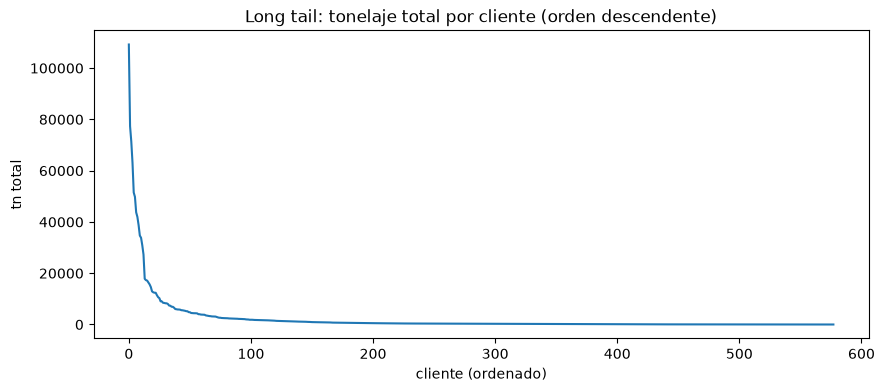

In [13]:
valores = tn_por_cliente["tn_total_cliente"].to_numpy()

plt.figure(figsize=(10, 4))
plt.plot(valores)
plt.title("Long tail: tonelaje total por cliente (orden descendente)")
plt.xlabel("cliente (ordenado)")
plt.ylabel("tn total")
plt.savefig(os.path.join(ruta, "long_tail.png"))
plt.show()

## 3. Particion en K clusters consecutivos (por orden de tonelaje)
Grupos de tamano igual en CANTIDAD DE CLIENTES. El diagnostico de abajo muestra cuantas filas (registros cliente-producto-periodo) le corresponden a cada grupo -- ajustar `k_clusters` si algun grupo es demasiado grande para la RAM disponible.

In [14]:
K = PARAM['k_clusters']
n_clientes = tn_por_cliente.height

tn_por_cliente = tn_por_cliente.with_row_index("orden")
tn_por_cliente = tn_por_cliente.with_columns(
    (pl.col("orden") * K // n_clientes).alias("cluster_id")
)

tb_clusters = tn_por_cliente.select(["customer_id", "cluster_id"])
print(tb_clusters.group_by("cluster_id").len().sort("cluster_id"))

shape: (10, 2)
┌────────────┬─────┐
│ cluster_id ┆ len │
│ ---        ┆ --- │
│ u32        ┆ u32 │
╞════════════╪═════╡
│ 0          ┆ 58  │
│ 1          ┆ 58  │
│ 2          ┆ 58  │
│ 3          ┆ 58  │
│ 4          ┆ 57  │
│ 5          ┆ 58  │
│ 6          ┆ 58  │
│ 7          ┆ 58  │
│ 8          ┆ 58  │
│ 9          ┆ 57  │
└────────────┴─────┘


In [15]:
df = df.join(tb_clusters, on="customer_id", how="left")

print("Filas (registros cliente-producto-periodo) por cluster:")
print(df.group_by("cluster_id").len().sort("cluster_id"))

Filas (registros cliente-producto-periodo) por cluster:
shape: (10, 2)
┌────────────┬─────────┐
│ cluster_id ┆ len     │
│ ---        ┆ ---     │
│ u32        ┆ u32     │
╞════════════╪═════════╡
│ 0          ┆ 1828276 │
│ 1          ┆ 1813178 │
│ 2          ┆ 1805186 │
│ 3          ┆ 1788206 │
│ 4          ┆ 1755783 │
│ 5          ┆ 1784409 │
│ 6          ┆ 1693055 │
│ 7          ┆ 1613495 │
│ 8          ┆ 1455078 │
│ 9          ┆ 1111400 │
└────────────┴─────────┘


## 4. Guardar
Si algun cluster salio demasiado grande en el diagnostico anterior, subir `k_clusters` y volver a correr desde la celda de PARAM.

In [16]:
salida = os.path.join(ruta, "tb_FE_CP_con_cluster.parquet")
df.write_parquet(salida)
print(salida)
print(df.shape)

/home/ds/exp/CP_CLUSTER_BRUTO/tb_FE_CP_con_cluster.parquet
(16648066, 67)
